In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Installing the required packages**

In [3]:
!pip install -r /content/drive/MyDrive/real_time_fraud_detection/requirements.txt

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)  #here we are setting the option of pandas to display all the columns
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)

**Reading the data**

In [5]:
df = pd.read_csv('/content/drive/MyDrive/real_time_fraud_detection/pay_sim.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
print(df.head())
print('---')
print(df.shape)
print('---')
print(df.info())
print('---')

   step      type    amount     nameorig  oldbalanceorg  newbalanceorig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      namedest  oldbalancedest  newbalancedest  isfraud  isflaggedfraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
---
(6362620, 11)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Dat

**Features discription**

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER. (categorical feature)

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction.

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

In [7]:
df.describe()

,step,amount,oldbalanceorg,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


As we can see from the above table that features such as amount, oldbalanceorg, newbalanceorig, oldbalancedest, newbalancedest are right skewed as their mean value is greater than median value.

**Function to reduce the memory size of a dataset**

In [8]:
from pandas.api.types import is_numeric_dtype
def reduce_memory(df,verbose=True):
    start_memory = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype   #extracting the type of column
        if is_numeric_dtype(df[col]) :  #only if the current column type is number, we change the memory accordingly to the type whether its integer or float
            c_min,c_max = df[col].min(),df[col].max()
            if np.issubdtype(col_type,np.integer):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif np.issubdtype(col_type,np.floating):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:  #if its a string then we change the type to category based on the number of unique values
           if (df[col].nunique() / len(df)) < 0.5:
                df[col] = df[col].astype('category')
    
    end_memory = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_memory:.2f} MB → {end_memory:.2f} MB '
              f'({100 * (start_memory - end_memory) / start_memory:.1f}% reduction)')
    
    return df
df = reduce_memory(df)

Memory usage: 533.97 MB → 309.78 MB (42.0% reduction)


**Data Preprocessing**

checking the null values in the dataset

In [9]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameorig,0
oldbalanceorg,0
newbalanceorig,0
namedest,0
oldbalancedest,0
newbalancedest,0
isfraud,0


As we can see there are no null values in the dataset. Now we will check for duplicates.

In [10]:
df.duplicated().sum()

np.int64(0)

There is also not a single duplicated record in the dataset. So we can say that there is no missing value and no duplicated record in the dataset.

In [11]:
def classify(df):
    target = 'isfraud'
    numerical = [feature for feature in df.select_dtypes(include=np.number).columns if feature!=target]
    categorical = [feature for feature in df.select_dtypes(exclude=np.number).columns if feature!=target]
    return numerical, categorical
numerical, categorical = classify(df)
print(f'Numerical features: {numerical}')
print(f'Categorical features: {categorical}')

Numerical features: ['step', 'amount', 'oldbalanceorg', 'newbalanceorig', 'oldbalancedest', 'newbalancedest', 'isflaggedfraud']
Categorical features: ['type', 'nameorig', 'namedest']


**EDA**

Checking the distribution of the target variable

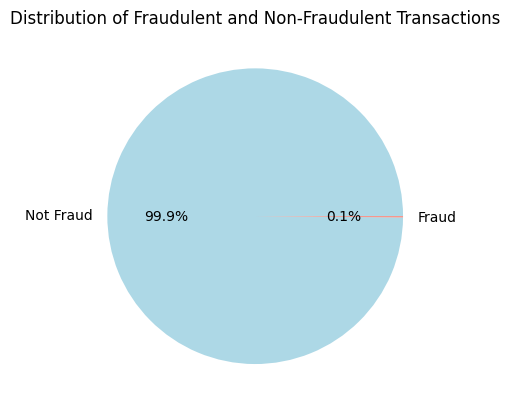

In [12]:
plt.pie(df['isfraud'].value_counts(),labels=['Not Fraud','Fraud'],autopct='%1.1f%%',colors=['lightblue','salmon'])
plt.title('Distribution of Fraudulent and Non-Fraudulent Transactions')
plt.show()

As we can observe that the dataset is highly imbalanced, with only 0.1% of positive class(fraud) and 99.9% of negative class(not fraud)

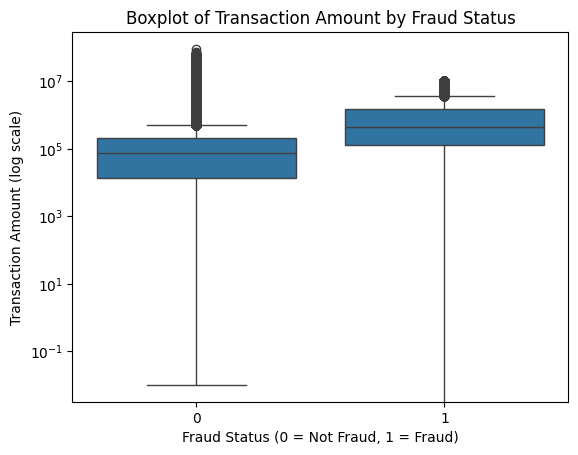

In [13]:
sns.boxplot(x='isfraud',y='amount',data=df)
plt.title('Boxplot of Transaction Amount by Fraud Status')
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Fraud Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount (log scale)')
plt.show()

Due to huge imbalance in dataset, the outliers in non fradulent transactions are dominating the plot as expected.

In [14]:
df['diff'] = abs(df['oldbalanceorg'] - df['newbalanceorig'])  #creating a new feature which is the difference between the old balance and the new balance after the transaction


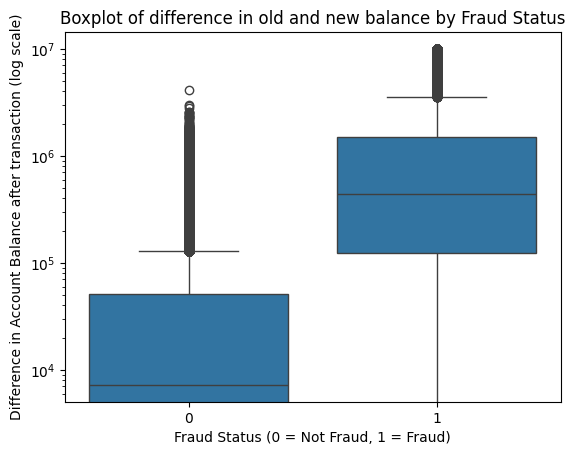

In [15]:
sns.boxplot(x='isfraud',y='diff',data=df)
plt.title('Boxplot of difference in old and new balance by Fraud Status')  
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Fraud Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Difference in Account Balance after transaction (log scale)')
plt.show()

As we can observe from the above plot that, the difference in new and old balance is very high for fraudulent transaction compared to non_fraudulent transaction.

In [16]:
df.columns

Index(['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud', 'diff'],
      dtype='object')

In [27]:
df['day'] = np.ceil(df['step'] / 24).astype(int)  #converting the time step into days by dividing the step by 24 and taking the ceiling to get the day number
df['day_name'] = df['day'].map({1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday',7:'Sunday'})  #mapping the day number to the day name

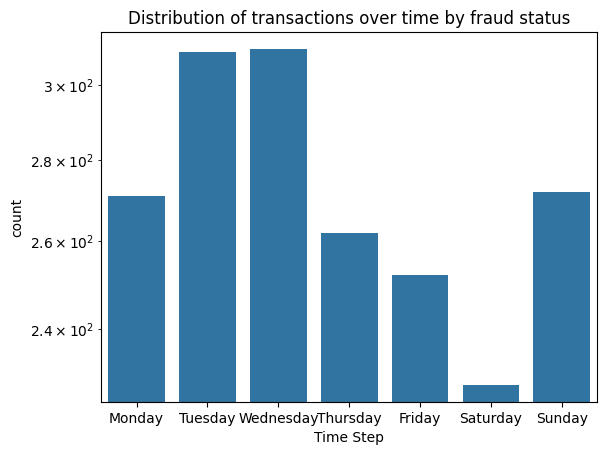

In [31]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='day_name',data=df[df['isfraud']==1],order=day_order)
plt.yscale('log')  # Log scale to better visualize the distribution
plt.title('Distribution of transactions over time by fraud status')
plt.xlabel('Time Step')
plt.show()

From the above plot, we can observe that there is a high fraudulent transaction on tuesday and wednesday

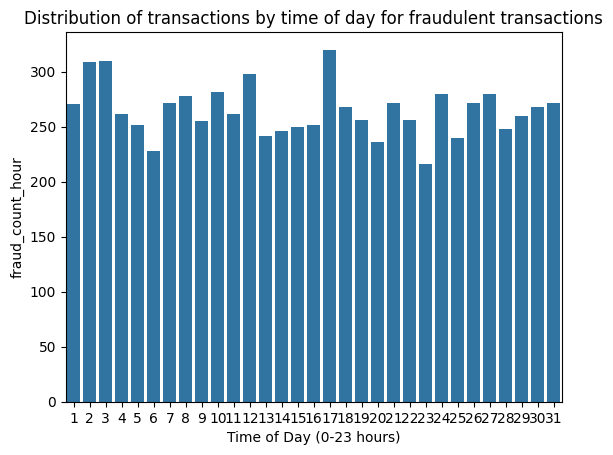

In [37]:
fraud_by_hour = df[df['isfraud']==1].groupby('day')['isfraud'].count().reset_index(name='fraud_count_hour')
sns.barplot(data=fraud_by_hour,x='day',y='fraud_count_hour')
plt.title('Distribution of transactions by time of day for fraudulent transactions')
plt.xlabel('Time of Day (0-23 hours)')
plt.show()